In [1]:
import os
from glob import glob

import click
import os
import numpy as np
from scipy.spatial import KDTree
from scipy.signal import convolve2d
from spectral.io import envi

import ast

import rasterio
from rasterio.merge import merge
from rasterio.windows import Window

from spectral.io import envi

import sys
sys.path.append('/store/carroll/repos/SpectralUtil/spectral_util')
import spec_io, mosaic

import matplotlib.pyplot as plt
import time
from osgeo import osr
import pyproj
import logging
from tqdm import tqdm
from copy import deepcopy
osr.UseExceptions()

%matplotlib widget

In [22]:
# weird fligthlines
# 29 28 27 26 25 (1 indexed)
weird = [x-1 for x in [25, 26, 27, 28, 29, 50]]
obs_list = '/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt'
with open(obs_list, 'r') as f:
    obs_list = f.readlines()
obs_list = [x.strip() for x in obs_list]

In [23]:
weird

[24, 25, 26, 27, 28, 49]

In [24]:
for idx, i in enumerate(obs_list):
    if idx in weird:
        print(idx, i)

24 /store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_154149_rdn_obs_ort
25 /store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_155226_rdn_obs_ort
26 /store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_160339_rdn_obs_ort
27 /store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_161406_rdn_obs_ort
28 /store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_162542_rdn_obs_ort
49 /store/carroll/col/data/2018/raw/L1/2018062113/NIS01_20180621_153047_rdn_obs_ort


In [20]:
fp = '/store/carroll/col/data/2018/deploy_3c_20251001/NIS01_20180619_154149/output/NIS01_20180619_154149_ewt.hdr'
ewt = envi.open(fp).open_memmap()
ewt.shape

(24427, 1545, 1)

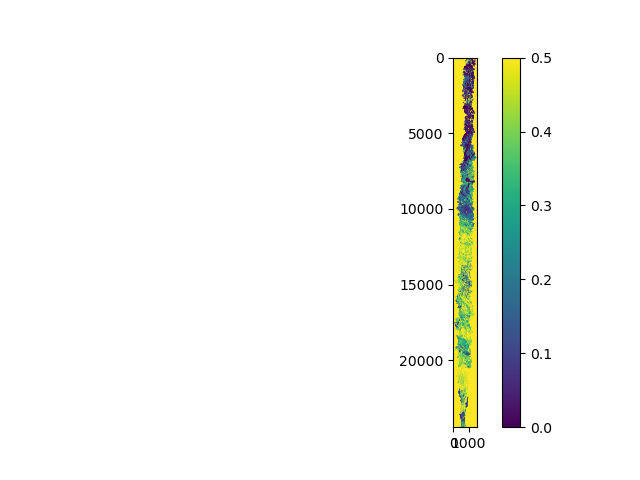

In [21]:
fig = plt.figure()
plt.imshow(ewt[...,0])
plt.colorbar()
plt.show()

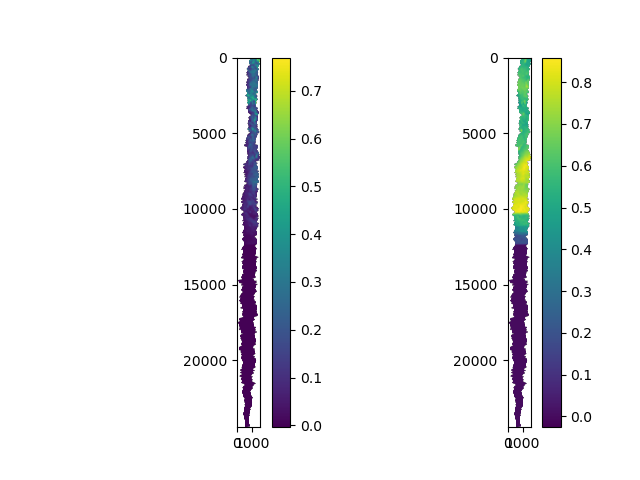

In [27]:
# is the atmosphere weird?
fp = '/store/carroll/col/data/2018/deploy_3c_20251001/NIS01_20180619_154149/output/NIS01_20180619_154149_atm_interp.hdr'
atm = envi.open(fp).open_memmap()

fig, axs = plt.subplots(ncols=2)

p0 = axs[0].imshow(atm[...,0])
p1 = axs[1].imshow(atm[...,1])

fig.colorbar(p0, ax=axs[0])
fig.colorbar(p1, ax=axs[1])

plt.show()

In [2]:
new_obs = '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_obs'
with rasterio.open(new_obs) as src:
    new_obs = src.read(9)
new_obs.shape

(26889, 21161)

In [5]:
new_obs[new_obs==-9999] = np.nan

In [3]:
phil_obs = '/store/brodrick/col/mosaics/built_mosaic/min_phase_obs.hdr'
phil_obs = envi.open(phil_obs).open_memmap()[...,8]
phil_obs.shape

(26450, 21640)

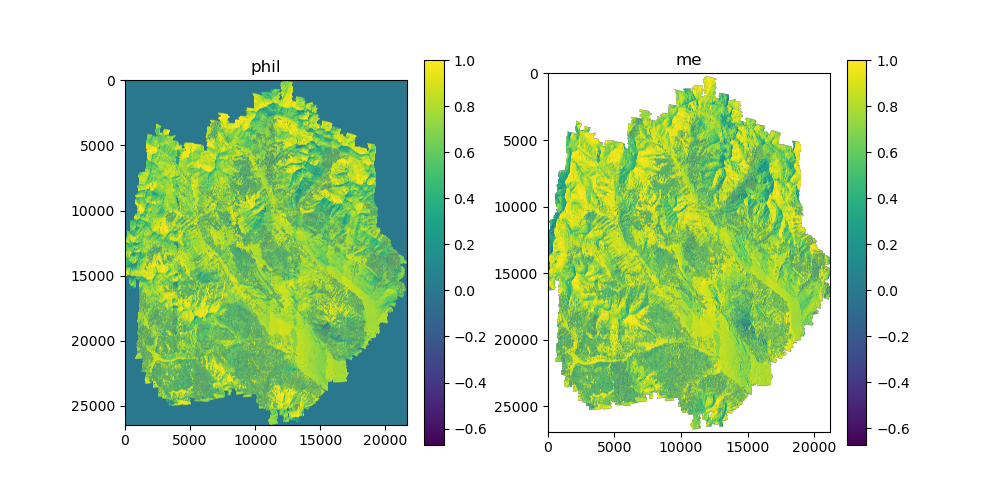

In [7]:
fig, axs = plt.subplots(ncols=2, figsize=(10,5))

p0 = axs[0].imshow(phil_obs)
axs[0].set_title('phil')

p1 = axs[1].imshow(new_obs)
axs[1].set_title('me')

fig.colorbar(p0, ax=axs[0])
fig.colorbar(p1, ax=axs[1])

plt.show()

In [41]:
new_glt = '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt.tif'
with rasterio.open(new_glt) as src:
    new_glt = src.read(3)
new_glt.shape

(26889, 21161)

In [36]:
phil_glt = '/store/brodrick/col/mosaics/built_mosaic/min_phase_glt.hdr'
phil_glt = envi.open(phil_glt).open_memmap()[...,2]
phil_glt.shape

(26450, 21640)

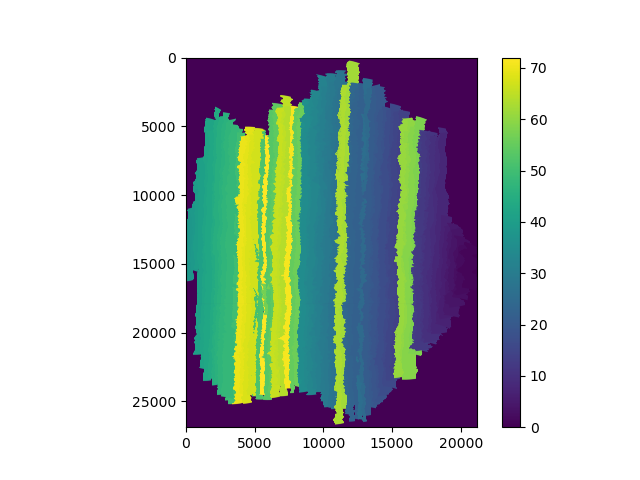

In [42]:
fig = plt.figure()
plt.imshow(new_glt)
plt.colorbar()
plt.show()

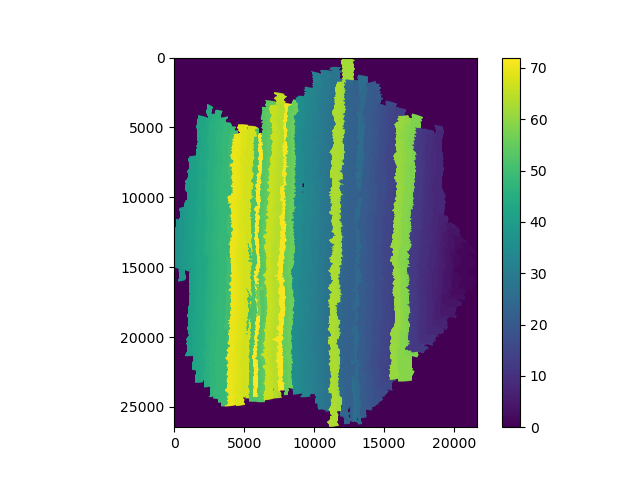

In [39]:
fig = plt.figure()
plt.imshow(phil_glt)
plt.colorbar()
plt.show()

In [44]:
diff = new_glt - phil_glt
diff.shape

ValueError: operands could not be broadcast together with shapes (26889,21161) (26450,21640) 

In [13]:
wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')
wl = wl[-26:,1]
wl.shape

(26,)

In [3]:
with rasterio.open('/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_rfl_400') as src:
    # window = Window(col_off=21161/2, row_off=26889/2, width=1024, height=1024) # clear flightline boundary
    window = Window(col_off=21161/2, row_off=26889/2, width=50, height=50)
    arr = src.read(window=window)
    # print(src.shape)
    print(src.count)

26


In [4]:
arr[arr==-9999] = np.nan

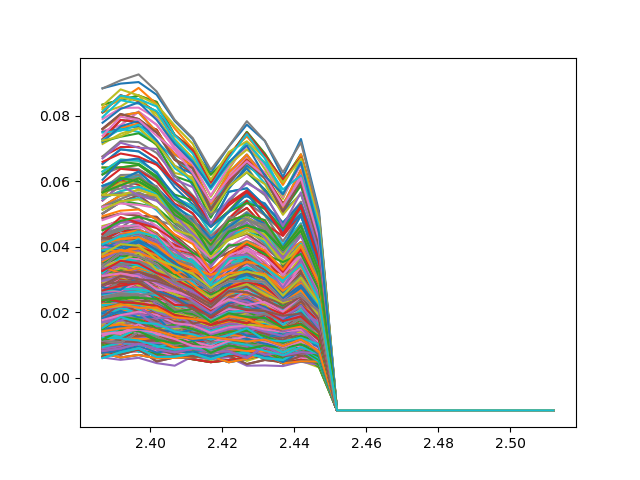

In [21]:
fig = plt.figure()
plt.plot(wl, arr.reshape(arr.shape[0], -1))
plt.show()

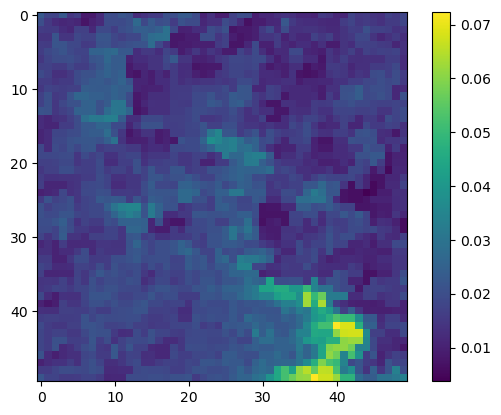

In [6]:
fig = plt.figure()
plt.imshow(arr[9,...])
plt.colorbar()
plt.show()

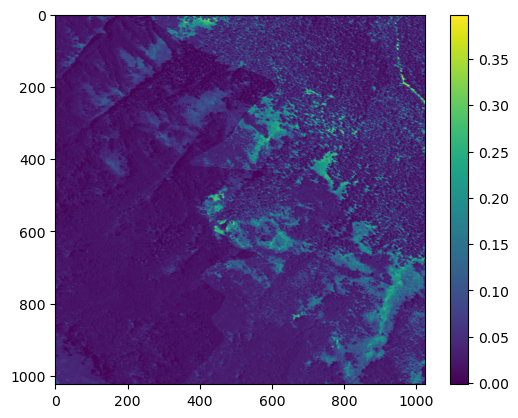

In [10]:
# fig = plt.figure()
# plt.imshow(arr)
# plt.colorbar()
# plt.show()

In [2]:
all_obs_files = '/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt'
glt_files = '/store/carroll/col/data/2018/mosaic/file_lists/joint_glt_file_list.txt'
obs_file_lists = '/store/carroll/col/data/2018/mosaic/file_lists/joint_obs_file_list.txt'

output_glt_file = '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt.tif'
output_file_list = '/store/carroll/col/data/2018/mosaic/file_lists/neon_2018_mosaic_joint_glt.txt'

ul_lr_grids = '/store/carroll/col/data/2018/mosaic/file_lists/ul_lr_grids.txt'

In [3]:
xs, ys = [], []
with open(ul_lr_grids) as f:
    for line in f:
        ulx, uly, lrx, lry = ast.literal_eval(line)
        xs.append(ulx); xs.append(lrx)
        ys.append(uly); ys.append(lry)
ul_lr = (min(xs), max(ys), max(xs), min(ys))
ul_lr

(316127.5833512874, 4324418.625222021, 337288.4827872183, 4297530.547926542)

In [4]:
output_file = output_glt_file
input_file_list = glt_files
x_resolution = 1
y_resolution = None
target_extent_ul_lr = ul_lr
output_epsg = 32613
n_cores = 1
max_distance = None
# log_file (str): Path to the log file.
# log_level (str): Logging verbosity.

In [5]:
if y_resolution is not None and y_resolution > 0:
    logging.warning("y_resolution is set to a positive value, which is not common.  Unless this is being done very intentionally, stop, and make y negative.")
elif y_resolution is None:
    y_resolution = -1 * x_resolution

input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]

gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

ul_lr = target_extent_ul_lr # in output epsg projection

In [6]:
trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)

y_grid_steps = np.arange(ul_lr[1], ul_lr[3] - trans[5]*0.01,trans[5])
x_grid_steps = np.arange(ul_lr[0], ul_lr[2] - trans[1]*0.01,trans[1])
y_grid, x_grid = np.meshgrid(y_grid_steps, 
                             x_grid_steps,
                             indexing='ij')

glt.shape, y_grid.shape, x_grid.shape

((26889, 21161, 3), (26889, 21161), (26889, 21161))

In [8]:
for _file, file in enumerate(tqdm(input_files, desc="Calculating GLT, File:", unit="files", ncols=80)):
    print(_file, file)

Calculating GLT, File:: 100%|███████████████| 9/9 [00:00<00:00, 55676.60files/s]

0 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
1 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
2 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
3 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
4 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
5 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4324418.625222021_330234.849641908_4315455.932790195.tif
6 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_330234.849641908_4306493.2403583685_337288.4827872183_4297530.547926542.tif
7 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic

In [9]:
_file = 0
file = input_files[0]
_file, file

(0,
 '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif')

In [11]:
sub_ul_lr = [float(x) for x in (file.removesuffix('.tif').split('_')[4:])]
sub_trans = [sub_ul_lr[0] - x_resolution/2., x_resolution, 0, 
             sub_ul_lr[1] - y_resolution/2., 0, y_resolution]
sub_y_grid_steps = np.arange(sub_ul_lr[1], sub_ul_lr[3] - sub_trans[5]*0.01,sub_trans[5])
sub_x_grid_steps = np.arange(sub_ul_lr[0], sub_ul_lr[2] - sub_trans[1]*0.01,sub_trans[1])
y_subgrid, x_subgrid = np.meshgrid(sub_y_grid_steps, sub_x_grid_steps, indexing='ij')

sub_glt, sub_glt_insert_idx = mosaic.find_subgrid_locations(y_grid, x_grid, y_subgrid, x_subgrid, n_workers=n_cores, max_distance=max_distance)
sub_glt.shape, sub_glt_insert_idx.shape

((8962, 7054, 2), (8962, 7054, 2))

In [12]:
with rasterio.open(file) as src:
    raw_glt = np.moveaxis(src.read(), 0, -1)

raw_glt.shape

(8963, 7054, 3)

In [13]:
sub_raw_glt = raw_glt[np.abs(sub_glt[...,1])-1, np.abs(sub_glt[...,0])-1]
sub_raw_glt.shape

(8962, 7054, 3)

In [14]:
valid =  np.logical_and(sub_glt[...,0] != meta.nodata_value, sub_raw_glt[...,0] != meta.nodata_value)
valid.shape

(8962, 7054)

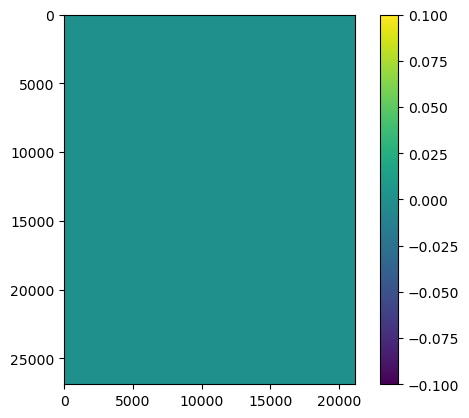

In [16]:
fig = plt.figure()
plt.imshow(glt[...,2])
plt.colorbar()
plt.show()

In [18]:
glt[sub_glt_insert_idx[valid,0], sub_glt_insert_idx[valid,1], 2] = sub_raw_glt[valid,2]

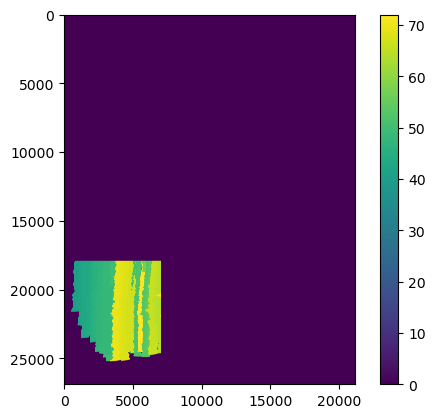

In [19]:
fig = plt.figure()
plt.imshow(glt[...,2])
plt.colorbar()
plt.show()

In [17]:
sub_glt_insert_idx[valid,0]

array([17926, 17926, 17926, ..., 25231, 25231, 25231])

In [70]:
raw_glt = sub_arr
raw_glt.shape

(8963, 7054, 3)

In [71]:
sub_glt.shape

(8962, 7054, 2)

In [72]:
sub_raw_glt = raw_glt[np.abs(sub_glt[...,1])-1, np.abs(sub_glt[...,0])-1]
sub_raw_glt.shape

(8962, 7054, 3)

In [76]:
valid =  np.logical_and(sub_glt[...,0] != meta.nodata_value, sub_raw_glt[...,0] != meta.nodata_value)
existing_crit.shape, valid.shape

((8962, 7054), (8962, 7054))

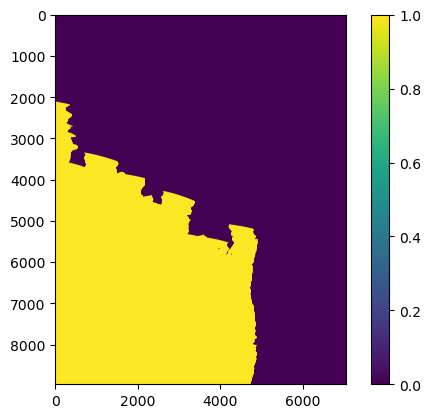

In [78]:
fig = plt.figure()
plt.imshow(valid)
plt.colorbar()
plt.show()

In [79]:
glt[sub_glt_insert_idx[valid,0], sub_glt_insert_idx[valid,1], :2] = sub_raw_glt[valid,:2]
glt[sub_glt_insert_idx[valid,0], sub_glt_insert_idx[valid,1], 2] = sub_raw_glt[valid,2]

In [9]:
for _file, file in enumerate(tqdm(input_files, desc="Calculating GLT, File:", unit="files", ncols=80)):
    print(_file, file)

Calculating GLT, File:: 100%|███████████████| 9/9 [00:00<00:00, 53317.42files/s]

0 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
1 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
2 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
3 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
4 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
5 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4324418.625222021_330234.849641908_4315455.932790195.tif
6 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_330234.849641908_4306493.2403583685_337288.4827872183_4297530.547926542.tif
7 /store/carroll/col/data/2018/mosaic/neon_2018_mosaic

In [41]:
_file = 0
file = input_files[0]
_file, file

(0,
 '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif')

In [42]:
sub_ul_lr = [float(x) for x in (file.removesuffix('.tif').split('_')[4:])]
sub_trans = [sub_ul_lr[0] - x_resolution/2., x_resolution, 0, 
             sub_ul_lr[1] - y_resolution/2., 0, y_resolution]
sub_y_grid_steps = np.arange(sub_ul_lr[1], sub_ul_lr[3] - sub_trans[5]*0.01,sub_trans[5])
sub_x_grid_steps = np.arange(sub_ul_lr[0], sub_ul_lr[2] - sub_trans[1]*0.01,sub_trans[1])
y_subgrid, x_subgrid = np.meshgrid(sub_y_grid_steps, sub_x_grid_steps, indexing='ij')

y_subgrid.shape, x_subgrid.shape

((8963, 7054), (8963, 7054))

In [44]:
y_grid_minor, x_grid_minor, y_start, x_start = mosaic.get_subgrid_from_bounds(y_grid, x_grid, (np.min(y_subgrid), np.max(y_subgrid)), (np.min(x_subgrid), np.max(x_subgrid)))
y_grid_minor.shape, x_grid_minor.shape, y_start, x_start

((8962, 7054), (8962, 7054), 17926, 0)

In [69]:
for file in input_files:
    print(file)
    with rasterio.open(file) as src:
        sub_arr = np.moveaxis(src.read(), 0, 2)
    
    sub_ul_lr = [float(x) for x in (file.removesuffix('.tif').split('_')[4:])]
    sub_trans = [sub_ul_lr[0] - x_resolution/2., x_resolution, 0, 
                 sub_ul_lr[1] - y_resolution/2., 0, y_resolution]
    sub_y_grid_steps = np.arange(sub_ul_lr[1], sub_ul_lr[3] - sub_trans[5]*0.01,sub_trans[5])
    sub_x_grid_steps = np.arange(sub_ul_lr[0], sub_ul_lr[2] - sub_trans[1]*0.01,sub_trans[1])
    y_subgrid, x_subgrid = np.meshgrid(sub_y_grid_steps, sub_x_grid_steps, indexing='ij')
    
    y_grid_minor, x_grid_minor, y_start, x_start = mosaic.get_subgrid_from_bounds(y_grid, x_grid, (np.min(y_subgrid), np.max(y_subgrid)), (np.min(x_subgrid), np.max(x_subgrid)))
    try:
        glt[y_start:y_start+sub_arr.shape[0], x_start:x_start+sub_arr.shape[1]] = sub_arr
    # tmp = glt[y_start:y_start+sub_arr.shape[0], x_start:x_start+sub_arr.shape[1]]
    except:
        print('fail')
    
    print(sub_arr.shape)
    print(y_subgrid.shape)
    print(x_subgrid.shape)
    print(y_grid_minor.shape)
    print(x_grid_minor.shape)
    # print(tmp.shape)

/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
(8963, 7054, 3)
(8963, 7054)
(8963, 7054)
(8962, 7054)
(8962, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
(8963, 7054, 3)
(8963, 7054)
(8963, 7054)
(8962, 7054)
(8962, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
(8963, 7054, 3)
(8963, 7054)
(8963, 7054)
(8963, 7054)
(8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
(8963, 7054, 3)
(8963, 7054)
(8963, 7054)
(8962, 7053)
(8962, 7053)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
(8963, 7054, 3)
(8963, 7054)
(8963, 7054)
(8962, 7053)
(8962,

In [50]:
y_grid_minor.shape

(8962, 7054)

In [68]:
tmp = glt[y_start:y_start+sub_arr.shape[0], x_start:]
tmp.shape

(8963, 7053, 3)

In [12]:
sub_glt, sub_glt_insert_idx = mosaic.find_subgrid_locations(y_grid, x_grid, y_subgrid, x_subgrid, n_workers=n_cores, max_distance=max_distance)

In [21]:
sub_glt.shape, sub_glt_insert_idx.shape

((8962, 7054, 2), (8962, 7054, 2))

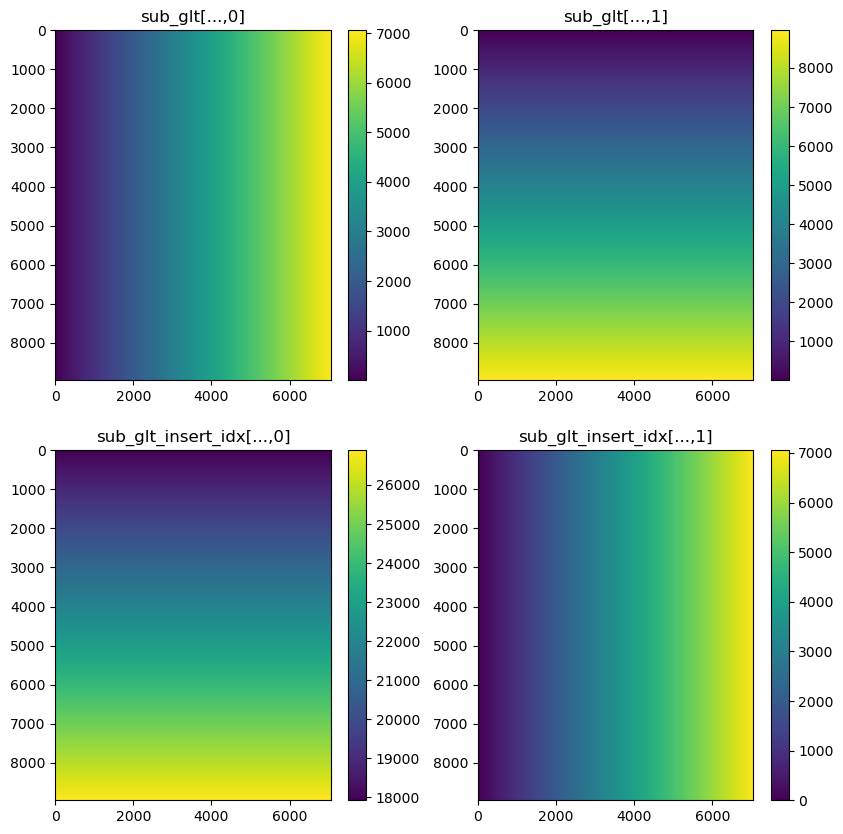

In [20]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10,10))

p00 = axs[0,0].imshow(sub_glt[...,0])
axs[0,0].set_title('sub_glt[...,0]')
fig.colorbar(p00, ax=axs[0,0])

p01 = axs[0,1].imshow(sub_glt[...,1])
axs[0,1].set_title('sub_glt[...,1]')
fig.colorbar(p01, ax=axs[0,1])

p10 = axs[1,0].imshow(sub_glt_insert_idx[...,0])
axs[1,0].set_title('sub_glt_insert_idx[...,0]')
fig.colorbar(p10, ax=axs[1,0])

p11 = axs[1,1].imshow(sub_glt_insert_idx[...,1])
axs[1,1].set_title('sub_glt_insert_idx[...,1]')
fig.colorbar(p11, ax=axs[1,1])

plt.show()

In [22]:
crit_mask = sub_glt[...,0] != 0 
crit_mask.shape

(8962, 7054)

In [33]:
np.min(sub_glt[...,0])

1

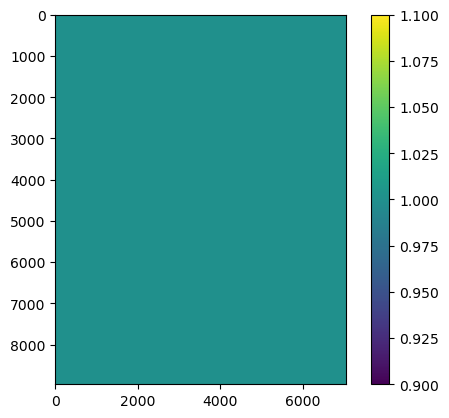

In [23]:
fig = plt.figure()
plt.imshow(crit_mask)
plt.colorbar()
plt.show()

In [25]:
sub_glt.shape

(8962, 7054, 2)

In [28]:
with rasterio.open(file) as src:
    sub_arr = np.moveaxis(src.read(), 0, 2)
sub_arr.shape

(8963, 7054, 3)

In [34]:
crit_mask.shape, sub_arr.shape

((8962, 7054), (8963, 7054, 3))

In [36]:
tmp = sub_arr[...,:2]
tmp.shape

(8963, 7054, 2)

In [51]:
crit_mask.shape, sub_glt_insert_idx.shape, sub_arr.shape

((8962, 7054), (8962, 7054, 2), (8963, 7054, 3))

In [32]:
glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], :2] = sub_arr[0:crit_mask.shape[],:2]
glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], 2] = sub_arr[crit_mask, 2]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 8963 but corresponding boolean dimension is 8962

In [38]:
tmp = glt[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1], :2]
tmp.shape

(8962, 7054, 2)

In [37]:
glt[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1], :2] = sub_arr[...,:2]
glt[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1], 2] = sub_arr[..., 2]

ValueError: shape mismatch: value array of shape (8963,7054,2) could not be broadcast to indexing result of shape (8962,7054,2)

In [39]:
tmp = sub_glt_insert_idx[...,0]
tmp

array([[17926, 17926, 17926, ..., 17926, 17926, 17926],
       [17927, 17927, 17927, ..., 17927, 17927, 17927],
       [17928, 17928, 17928, ..., 17928, 17928, 17928],
       ...,
       [26885, 26885, 26885, ..., 26885, 26885, 26885],
       [26886, 26886, 26886, ..., 26886, 26886, 26886],
       [26887, 26887, 26887, ..., 26887, 26887, 26887]])

In [ ]:
# glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], :2] = sub_glt[crit_mask,:]
# glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], 2] = _file + 1

In [29]:
glt.shape

(26889, 21161, 3)

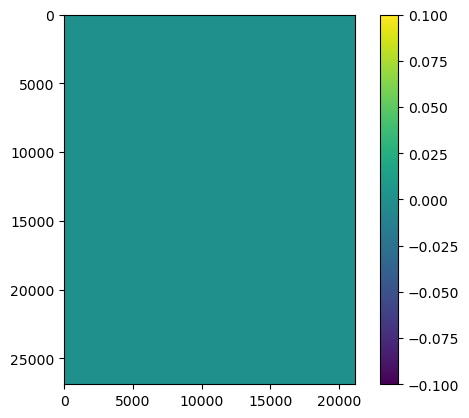

In [30]:
fig = plt.figure()
plt.imshow(glt[...,2])
plt.colorbar()
plt.show()

In [252]:
for fp in fps:
    print(fp)
    sub_ul_lr = [float(x) for x in (fp.removesuffix('.tif').split('_')[4:])]
    sub_trans = [sub_ul_lr[0] - x_resolution/2., x_resolution, 0, 
                 sub_ul_lr[1] - y_resolution/2., 0, y_resolution]
    sub_y_grid_steps = np.arange(sub_ul_lr[1], sub_ul_lr[3] - sub_trans[5]*0.01,sub_trans[5])
    sub_x_grid_steps = np.arange(sub_ul_lr[0], sub_ul_lr[2] - sub_trans[1]*0.01,sub_trans[1])
    y_subgrid, x_subgrid = np.meshgrid(sub_y_grid_steps, 
                                       sub_x_grid_steps,
                                       indexing='ij')
    with rasterio.open(fp) as src:
        print(src.shape)

    print(y_subgrid.shape)
    print(x_subgrid.shape)

/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
(8963, 7054)
(8963, 7054)
(8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
(8963, 7054)
(8963, 7054)
(8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
(8963, 7054)
(8963, 7054)
(8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
(8963, 7054)
(8963, 7054)
(8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
(8963, 7054)
(8963, 7054)
(8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4324418.625222021_330234.849641908_4315455.932790195.tif
(8963,

In [246]:
fp = fps[0]
print(fp)
sub_ul_lr = [float(x) for x in (fp.removesuffix('.tif').split('_')[4:])]
sub_ul_lr

/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif


[316127.5833512874, 4306493.2403583685, 323181.2164965977, 4297530.547926542]

In [248]:
sub_trans = [sub_ul_lr[0] - x_resolution/2., x_resolution, 0, 
             sub_ul_lr[1] - y_resolution/2., 0, y_resolution]
sub_trans

[316127.0833512874, 1, 0, 4306493.7403583685, 0, -1]

In [249]:
sub_y_grid_steps = np.arange(sub_ul_lr[1], sub_ul_lr[3] - sub_trans[5]*0.01,sub_trans[5])
sub_x_grid_steps = np.arange(sub_ul_lr[0], sub_ul_lr[2] - sub_trans[1]*0.01,sub_trans[1])
y_subgrid, x_subgrid = np.meshgrid(sub_y_grid_steps, 
                                   sub_x_grid_steps,
                                   indexing='ij')

In [250]:
y_subgrid.shape, x_subgrid.shape

((8963, 7054), (8963, 7054))

In [245]:
sub_glt = np.zeros(( int(np.ceil((sub_ul_lr[3] - sub_ul_lr[1]) / y_resolution)), 
                 int(np.ceil((sub_ul_lr[2] - sub_ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
sub_glt.shape

(8963, 7054, 3)

In [57]:
srcs = [rasterio.open(x) for x in input_files]
mosaic_, out_transform = merge(
    srcs,
    method='first',
    precision=1  # tells rasterio when grids can be treated as aligned
)

In [58]:
mosaic_.shape

(3, 26888, 21161)

In [62]:
with rasterio.open(
    output_glt_file,
    "w",
    driver="GTiff",
    height=mosaic_.shape[1],
    width=mosaic_.shape[2],
    count=mosaic_.shape[0],
    dtype=mosaic_.dtype,
    crs="EPSG:32613",
    transform=out_transform,
    compress="lzw",
    tiled=True
) as dst:
    dst.write(mosaic_)

In [242]:
sub_arr.shape

(8963, 7054, 3)

In [225]:
output_file = output_glt_file
glt_files = glt_files

x_resolution = 1
y_resolution = -1
output_epsg = 32613

# get ul, lr across grids
xs, ys = [], []
with open(ul_lr_grids) as f:
    for line in f:
        ulx, uly, lrx, lry = ast.literal_eval(line)
        xs.append(ulx); xs.append(lrx)
        ys.append(uly); ys.append(lry)
main_ul_lr = (min(xs), max(ys), max(xs), min(ys))

glt, glt_meta = merge_joint_glts(output_glt_file, glt_files, main_ul_lr, x_resolution=x_resolution, y_resolution=y_resolution, output_epsg=output_epsg)

/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4324418.625222021_330234.849641908_4315455.932790195.tif
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_330234.849641908_4306493.2403583685_337288.4827872183_4297530.547926542.tif


ValueError: could not broadcast input array from shape (8963,7054,3) into shape (8963,7053,3)

In [235]:
# set up full empty grid
gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

trans = [main_ul_lr[0] - x_resolution/2., x_resolution, 0, 
         main_ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)
glt = np.zeros(( int(np.ceil((main_ul_lr[3] - main_ul_lr[1]) / y_resolution)), 
                 int(np.ceil((main_ul_lr[2] - main_ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
y_grid_steps = np.arange(main_ul_lr[1], main_ul_lr[3] - trans[5]*0.01,trans[5])
x_grid_steps = np.arange(main_ul_lr[0], main_ul_lr[2] - trans[1]*0.01,trans[1])
y_grid, x_grid = np.meshgrid(y_grid_steps, 
                             x_grid_steps,
                             indexing='ij')

glt.shape

(26889, 21161, 3)

In [236]:
for fp in fps:
    print(fp)
    
    # identify y_start, x_start for subgrid
    sub_ul_lr = [float(x) for x in (fp.removesuffix('.tif').split('_')[4:])]
    y_bounds = [sub_ul_lr[3], sub_ul_lr[1]]
    x_bounds = [sub_ul_lr[0], sub_ul_lr[2]]
    y_grid_minor, x_grid_minor, y_start, x_start = mosaic.get_subgrid_from_bounds(y_grid, x_grid, y_bounds, x_bounds)

    # insert subgrid values to main grid
    with rasterio.open(fp) as src:
        sub_arr = np.moveaxis(src.read(),0,2) # to match envi conventions

    print(sub_arr.shape)
    tmp = glt[y_start:y_start+sub_arr.shape[0], x_start:x_start+sub_arr.shape[1], :]
    print(tmp.shape)


/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
(8963, 7054, 3)
(8963, 7054, 3)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
(8963, 7054, 3)
(8963, 7054, 3)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
(8963, 7054, 3)
(8963, 7054, 3)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
(8963, 7054, 3)
(8963, 7054, 3)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
(8963, 7054, 3)
(8963, 7054, 3)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4324418.625222021_330234.849641908_4315455.932790195.tif
(8963, 7054, 3)
(8963, 7054, 3)
/store/ca

In [228]:
fp = '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_330234.849641908_4306493.2403583685_337288.4827872183_4297530.547926542.tif'
sub_ul_lr = [float(x) for x in (fp.removesuffix('.tif').split('_')[4:])]
y_bounds = [sub_ul_lr[3], sub_ul_lr[1]]
x_bounds = [sub_ul_lr[0], sub_ul_lr[2]]
y_grid_minor, x_grid_minor, y_start, x_start = mosaic.get_subgrid_from_bounds(y_grid, x_grid, y_bounds, x_bounds)

In [230]:
y_grid_minor.shape, x_grid_minor.shape, y_start, x_start

((8963, 7053), (8963, 7053), 17926, 14108)

In [233]:
for fp in fps:
    print(fp)
    with rasterio.open(fp) as src:
        sub_arr = src.read() # to match envi conventions
    print(sub_arr.shape)
# sub_arr.shape

/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
(3, 8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4315455.932790195_323181.2164965977_4306493.2403583685.tif
(3, 8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4324418.625222021_323181.2164965977_4315455.932790195.tif
(3, 8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4306493.2403583685_330234.849641908_4297530.547926542.tif
(3, 8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4315455.932790195_330234.849641908_4306493.2403583685.tif
(3, 8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_323181.2164965977_4324418.625222021_330234.849641908_4315455.932790195.tif
(3, 8963, 7054)
/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_330234.849641908_4306493.2403583685_337288.48278

In [234]:
tmp = glt[y_start:y_start+sub_arr.shape[0], x_start:x_start+sub_arr.shape[1], :]
tmp.shape

(3, 7053, 3)

In [156]:
x_resolution = 1
y_resolution = -1
output_epsg = 32613

# get ul, lr across grids
xs, ys = [], []
with open(ul_lr_grids) as f:
    for line in f:
        ulx, uly, lrx, lry = ast.literal_eval(line)
        xs.append(ulx); xs.append(lrx)
        ys.append(uly); ys.append(lry)
ul_lr = (min(xs), max(ys), max(xs), min(ys))

print("Bounding box (ul_lr): " + str(ul_lr)) 

Bounding box (ul_lr): (316127.5833512874, 4324418.625222021, 337288.4827872183, 4297530.547926542)


In [157]:
gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

In [158]:
trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

In [159]:
glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
glt.shape

(26889, 21161, 3)

In [160]:
y_grid_steps = np.arange(ul_lr[1], ul_lr[3] - trans[5]*0.01,trans[5])
x_grid_steps = np.arange(ul_lr[0], ul_lr[2] - trans[1]*0.01,trans[1])
y_grid, x_grid = np.meshgrid(y_grid_steps, 
                             x_grid_steps,
                             indexing='ij')

In [164]:
y_grid_steps.shape, x_grid_steps.shape, y_grid.shape, x_grid.shape

((26889,), (21161,), (26889, 21161), (26889, 21161))

In [197]:
with open(glt_files, 'r') as f:
    fps = f.readlines()
fps = [x.strip() for x in fps]
fp = fps[0]
sub_ul_lr = [float(x) for x in (fp.removesuffix('.tif').split('_')[4:])]

with rasterio.open(fp) as src:
    sub_arr = np.moveaxis(src.read(),0,2) # to match envi conventions

# sub_trans = [sub_ul_lr[0] - x_resolution/2., x_resolution, 0, 
#          sub_ul_lr[1] - y_resolution/2., 0, y_resolution]

# sub_y_grid_steps = np.arange(sub_ul_lr[1], sub_ul_lr[3] - sub_trans[5]*0.01,sub_trans[5])
# sub_x_grid_steps = np.arange(sub_ul_lr[0], sub_ul_lr[2] - sub_trans[1]*0.01,sub_trans[1])
# y_subgrid, x_subgrid = np.meshgrid(sub_y_grid_steps, 
#                              sub_x_grid_steps,
#                              indexing='ij')

y_bounds = [sub_ul_lr[3], sub_ul_lr[1]]
x_bounds = [sub_ul_lr[0], sub_ul_lr[2]]

print(fp)
print(sub_arr.shape)
y_bounds, x_bounds

/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_316127.5833512874_4306493.2403583685_323181.2164965977_4297530.547926542.tif
(8963, 7054, 3)


([4297530.547926542, 4306493.2403583685],
 [316127.5833512874, 323181.2164965977])

In [198]:
# y_grid_minor, x_grid_minor, y_start, x_start = get_subgrid_from_bounds(y_grid, x_grid, (np.min(y_subgrid), np.max(y_subgrid)), (np.min(x_subgrid), np.max(x_subgrid)))
y_grid_minor, x_grid_minor, y_start, x_start = mosaic.get_subgrid_from_bounds(y_grid, x_grid, y_bounds, x_bounds)

In [199]:
y_grid_minor.shape, x_grid_minor.shape, y_start, x_start

((8963, 7054), (8963, 7054), 17926, 0)

In [201]:
# insert local values
glt[y_start:y_start+sub_arr.shape[0], x_start:x_start+sub_arr.shape[1], :] = sub_arr

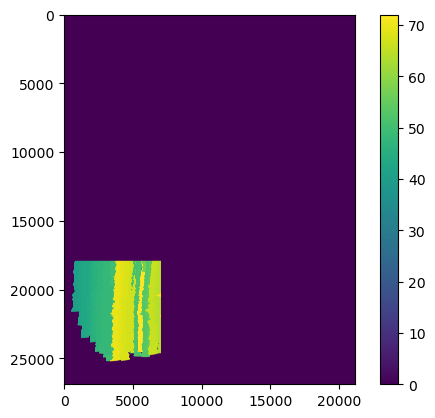

In [202]:
fig = plt.figure()

plt.imshow(glt[...,2])

plt.colorbar()

plt.show()

In [237]:
with open(glt_files, 'r') as f:
    fps = f.readlines()
fps = [x.strip() for x in fps]
fp = fps[0]
fp
srcs = [rasterio.open(fp) for fp in fps]

In [186]:
srcs[0].shape

(8963, 7054)

In [238]:
mosaic, out_transform = merge(
    srcs,
    method='first',
    precision=1  # tells rasterio when grids can be treated as aligned
)

/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/rasterio/merge.py:217: RasterioDeprecationWarning: The precision parameter is unused, deprecated, and will be removed in 2.0.0.
  warnings.warn(


In [239]:
mosaic.shape

(3, 26888, 21161)

In [2]:
# define filepaths

home = '/store/carroll/col/data/2018/mosaic/'

output_file = '/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt.tif'
input_file_list = '/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt'
ignore_file_list = None
x_resolution = 1
y_resolution = None
target_extent_ul_lr = None
output_epsg = 32613
criteria_band = 5
criteria_mode = 'min'
n_cores = 1
max_distance = None

In [4]:
# new goal is to make extents
input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]

In [8]:
gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

if target_extent_ul_lr:
    ul_lr = target_extent_ul_lr # in output epsg projection
else:
    # Always gets this in 4326
    ul_lr = mosaic.get_ul_lr_from_files(input_files, get_resolution=False)
    # convert to output epsg
    ul = proj(ul_lr[0], ul_lr[1])
    lr = proj(ul_lr[2], ul_lr[3])
    ul_lr = [ul[0], ul[1], lr[0], lr[1]]

ul_lr

[316127.5833512874, 4324418.625222021, 337288.4827872183, 4297530.547926542]

In [11]:
# split into 9?
n = 3

xmin, ymax, xmax, ymin = ul_lr
dx = (xmax - xmin) / n
dy = (ymax - ymin) / n
dx, dy

(7053.633145310295, 8962.692431826144)

In [13]:
lis_ul_lr = []

for row in range(n):
    ul_y = ymax - row * dy
    lr_y = ymax - (row + 1) * dy
    for col in range(n):
        ul_x = xmin + col * dx
        lr_x = xmin + (col + 1) * dx
        lis_ul_lr.append([ul_x, ul_y, lr_x, lr_y])

lis_ul_lr

[[316127.5833512874, 4324418.625222021, 323181.2164965977, 4315455.932790195],
 [323181.2164965977, 4324418.625222021, 330234.849641908, 4315455.932790195],
 [330234.849641908, 4324418.625222021, 337288.4827872183, 4315455.932790195],
 [316127.5833512874, 4315455.932790195, 323181.2164965977, 4306493.2403583685],
 [323181.2164965977, 4315455.932790195, 330234.849641908, 4306493.2403583685],
 [330234.849641908, 4315455.932790195, 337288.4827872183, 4306493.2403583685],
 [316127.5833512874, 4306493.2403583685, 323181.2164965977, 4297530.547926542],
 [323181.2164965977, 4306493.2403583685, 330234.849641908, 4297530.547926542],
 [330234.849641908, 4306493.2403583685, 337288.4827872183, 4297530.547926542]]

In [26]:
# generate mosiac glt for each tile
import ast

ul_lr_grids = '/store/carroll/col/data/2018/mosaic/file_lists/ul_lr_grids.txt'
with open(ul_lr_grids, 'r') as f:
    ul_lr_grids = f.readlines()
ul_lr_grids = [ast.literal_eval(x.strip()) for x in ul_lr_grids]
ul_lr_grids

[[316127.5833512874, 4324418.625222021, 323181.2164965977, 4315455.932790195],
 [323181.2164965977, 4324418.625222021, 330234.849641908, 4315455.932790195],
 [330234.849641908, 4324418.625222021, 337288.4827872183, 4315455.932790195],
 [316127.5833512874, 4315455.932790195, 323181.2164965977, 4306493.2403583685],
 [323181.2164965977, 4315455.932790195, 330234.849641908, 4306493.2403583685],
 [330234.849641908, 4315455.932790195, 337288.4827872183, 4306493.2403583685],
 [316127.5833512874, 4306493.2403583685, 323181.2164965977, 4297530.547926542],
 [323181.2164965977, 4306493.2403583685, 330234.849641908, 4297530.547926542],
 [330234.849641908, 4306493.2403583685, 337288.4827872183, 4297530.547926542]]

In [30]:
for idx, ul_lr in enumerate(ul_lr_grids):
    print(idx, ul_lr)

0 [316127.5833512874, 4324418.625222021, 323181.2164965977, 4315455.932790195]
1 [323181.2164965977, 4324418.625222021, 330234.849641908, 4315455.932790195]
2 [330234.849641908, 4324418.625222021, 337288.4827872183, 4315455.932790195]
3 [316127.5833512874, 4315455.932790195, 323181.2164965977, 4306493.2403583685]
4 [323181.2164965977, 4315455.932790195, 330234.849641908, 4306493.2403583685]
5 [330234.849641908, 4315455.932790195, 337288.4827872183, 4306493.2403583685]
6 [316127.5833512874, 4306493.2403583685, 323181.2164965977, 4297530.547926542]
7 [323181.2164965977, 4306493.2403583685, 330234.849641908, 4297530.547926542]
8 [330234.849641908, 4306493.2403583685, 337288.4827872183, 4297530.547926542]


In [8]:
if y_resolution is not None and y_resolution > 0:
    logging.warning("y_resolution is set to a positive value, which is not common.  Unless this is being done very intentionally, stop, and make y negative.")
elif y_resolution is None:
    y_resolution = -1 * x_resolution
print(x_resolution, y_resolution)

if input_file_list.endswith(".nc"):
    input_files = [input_file_list]
else:
    input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]

ignore_files = []
if ignore_file_list is not None:
    ignore_files = [x.strip() for x in open(ignore_file_list, 'r').readlines()]

gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

1 -1


In [9]:
if target_extent_ul_lr:
    ul_lr = target_extent_ul_lr # in output epsg projection
else:
    # Always gets this in 4326
    ul_lr = mosaic.get_ul_lr_from_files(input_files, get_resolution=False)
    # convert to output epsg
    ul = proj(ul_lr[0], ul_lr[1])
    lr = proj(ul_lr[2], ul_lr[3])
    ul_lr = [ul[0], ul[1], lr[0], lr[1]]

if str(output_epsg)[0] == "4" and x_resolution > 1:
    raise ValueError(f"x_resolution is {x_resolution} (indicating meters), and EPSG is {output_epsg}.  Smells like lat/lon and UTM mismatch.  Terminating.")

print("Bounding box (ul_lr): " + str(ul_lr)) 

Bounding box (ul_lr): [316127.5833512874, 4324418.625222021, 337288.4827872183, 4297530.547926542]


In [12]:
trans

[316127.0833512874, 1, 0, 4324419.125222021, 0, -1]

In [11]:
trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
criteria = np.zeros((glt.shape[0], glt.shape[1]), dtype=np.float32)
criteria[...] = np.nan

y_grid_steps = np.arange(ul_lr[1], ul_lr[3] - trans[5]*0.01,trans[5])
x_grid_steps = np.arange(ul_lr[0], ul_lr[2] - trans[1]*0.01,trans[1])
y_grid, x_grid = np.meshgrid(y_grid_steps, 
                             x_grid_steps,
                             indexing='ij')

In [ ]:
# what if here I stop and - 
glt_x = x_grid
glt_y = y_grid
file_index = x_grid.copy()

In [15]:
glt.shape

(26889, 21161, 3)

In [17]:
_file = 0
file = input_files[0]
print(_file, file)

0 /store/carroll/col/data/2018/raw/L1/2018061214/NIS01_20180612_154959_rdn_obs_ort


In [19]:
nodata_fallback = -9999
with rasterio.open(file) as src2:
    # # --- use raster 1 as the reference grid ---
    # ref_crs = src1.crs
    # ref_transform = src1.transform
    # height, width = src1.height, src1.width

    # # read criteria band from raster 1
    # band1 = src1.read(criteria_band)
    # nodata1 = src1.nodata if src1.nodata is not None else nodata_fallback

    ref_crs = output_epsg
    ref_transform = trans
    height = glt.shape[0]
    width = glt.shape[1]
    band1 = glt
    
    # reproject criteria band from raster 2 to raster 1's grid
    band2 = np.full((height, width), nodata_fallback, dtype=band1.dtype)
    reproject(
        source=rasterio.band(src2, criteria_band),
        destination=band2,
        src_transform=src2.transform,
        src_crs=src2.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=nodata_fallback,
        resampling=Resampling.nearest,   # or bilinear, etc.
    )
    nodata2 = src2.nodata if src2.nodata is not None else nodata_fallback

TypeError: GDAL-style transforms have been deprecated.  This exception will be raised for a period of time to highlight potentially confusing errors, but will eventually be removed.

In [13]:
glt.shape, criteria.shape

((26889, 21161, 3), (26889, 21161))

In [7]:
y_grid.shape, x_grid.shape

((26889, 21161), (26889, 21161))

In [16]:
_file = 0
file = input_files[0]
print(_file, file)

0 /store/carroll/col/data/2018/raw/L1/2018061214/NIS01_20180612_154959_rdn_obs_ort


In [13]:
local_meta, obs = spec_io.load_data(file.strip(), lazy=True, load_glt=False, load_loc=True)
print(obs.shape)

(3562, 1631, 11)


In [14]:
loc_file = file.replace('obs_ort','ort_igm_ort')+'.hdr' # for NEON-formatted envi files
loc = envi.open(loc_file).open_memmap()[...,0:2]
print(loc.shape)

(3562, 1631, 2)


In [17]:
y_subgrid = loc[...,1]
x_subgrid = loc[...,0]
y_grid_minor, x_grid_minor, y_start, x_start = mosaic.get_subgrid_from_bounds(y_grid, x_grid, (np.min(y_subgrid), np.max(y_subgrid)), (np.min(x_subgrid), np.max(x_subgrid)))
y_grid_minor.shape, x_grid_minor.shape, y_start, x_start

((13476, 21161), (13476, 21161), 13413, 0)

In [18]:
main_grid_points = np.column_stack((y_grid_minor.ravel(), x_grid_minor.ravel()))

# Flatten the subgrid coordinates
subgrid_points = np.column_stack((y_subgrid.ravel(), x_subgrid.ravel()))

main_grid_points.shape, subgrid_points.shape

((285165636, 2), (5809622, 2))

In [20]:
# this is really fast
st = time.time()
tree = KDTree(subgrid_points)
print(f"Time to build tree: {time.time() - st}")

Time to build tree: 1.108036994934082


In [ ]:
st = time.time()
distances, indices = tree.query(main_grid_points, workers=1) # this is the thing that takes forever?
print(f"Time to querry tree: {time.time() - st}")

In [4]:
# trying my way....

obs_file_list = '/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt'
criteria_band = 6   # 1-based index for rasterio; change as needed
nodata_value  = -9999  # change to your nodata if different

In [5]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
